<a href="https://colab.research.google.com/github/BrooksInGit/AI-ML-Coursework/blob/main/JamesBrooks_Full_Code_SuperKart_Model_Deployment_Notebook_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Load the dataset
kart = pd.read_csv('/content/drive/MyDrive/SuperKart.csv')

# Display the first 5 rows of the dataframe
display(kart.head())

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [5]:
data = kart.copy()

# **Data Overview**

In [6]:
print("--- First 5 rows of the DataFrame ---")
display(data.head())
print("\n" + "="*50 + "\n")

print("--- DataFrame Information (data.info()) ---")
data.info()
print("\n" + "="*50 + "\n")

print("--- Missing Values (data.isnull().sum()) ---")
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0]) # Display only columns with missing values
if missing_values.sum() == 0:
    print("No missing values found in the dataset.")
print("\n" + "="*50 + "\n")

print("--- Duplicate Rows (data.duplicated().sum()) ---")
num_duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")
if num_duplicates > 0:
    print("Consider removing duplicate rows if they are exact copies and not legitimate repeated observations.")
print("\n" + "="*50 + "\n")

print("--- DataFrame Shape (data.shape) ---")
print(f"The DataFrame has {data.shape[0]} rows and {data.shape[1]} columns.")
print("\n" + "="*50 + "\n")

--- First 5 rows of the DataFrame ---


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36




--- DataFrame Information (data.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis


### Univariate Analysis ###

Numerical Columns for Analysis: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year', 'Product_Store_Sales_Total']
Categorical Columns for Analysis: ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']


### Univariate Analysis: Numerical Variables ###

--- Descriptive Statistics for Numerical Columns ---
       Product_Weight  Product_Allocated_Area  Product_MRP  \
count     8763.000000             8763.000000  8763.000000   
mean        12.653792                0.068786   147.032539   
std          2.217320                0.048204    30.694110   
min          4.000000                0.004000    31.000000   
25%         11.150000                0.031000   126.160000   
50%         12.660000                0.056000   146.740000   
75%         14.180000                0.096000   167.585000   
max         22.000000                0.298000   266.000000   

       Store_Establishmen

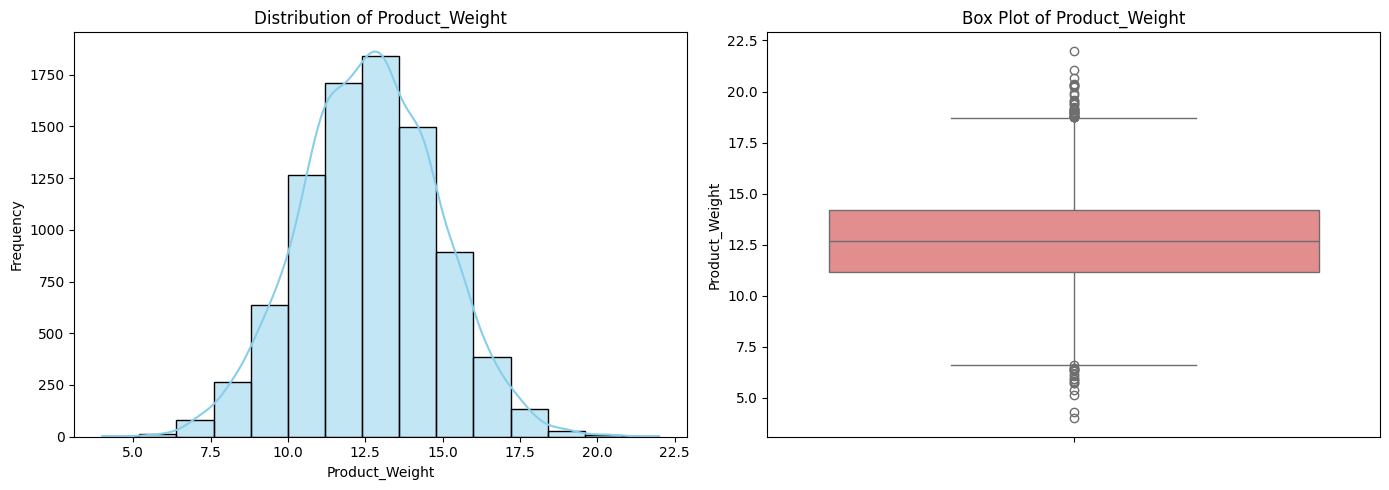

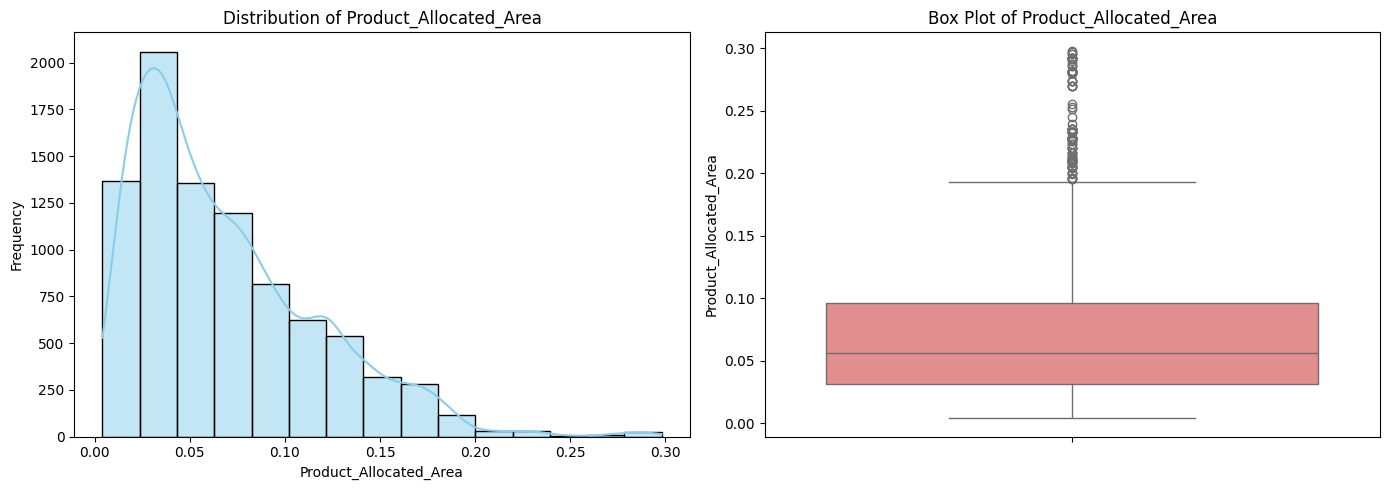

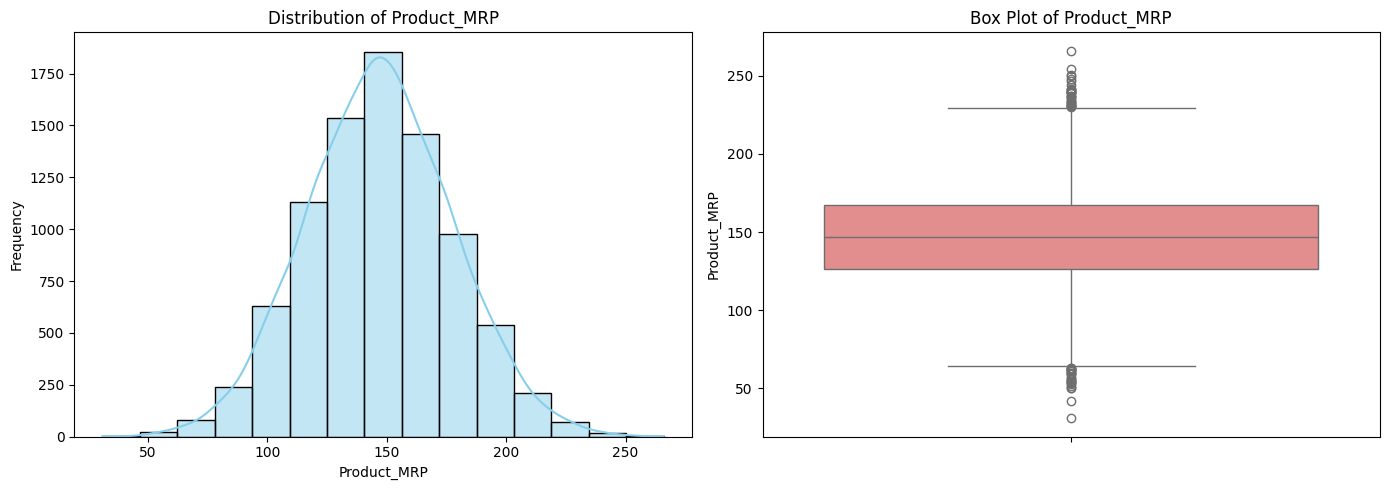

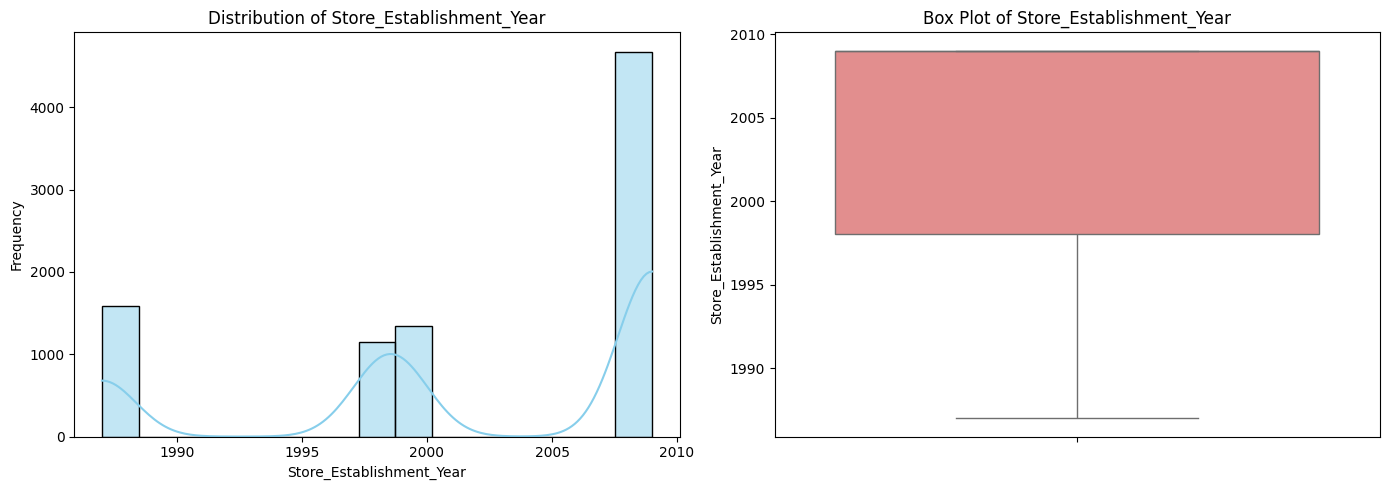

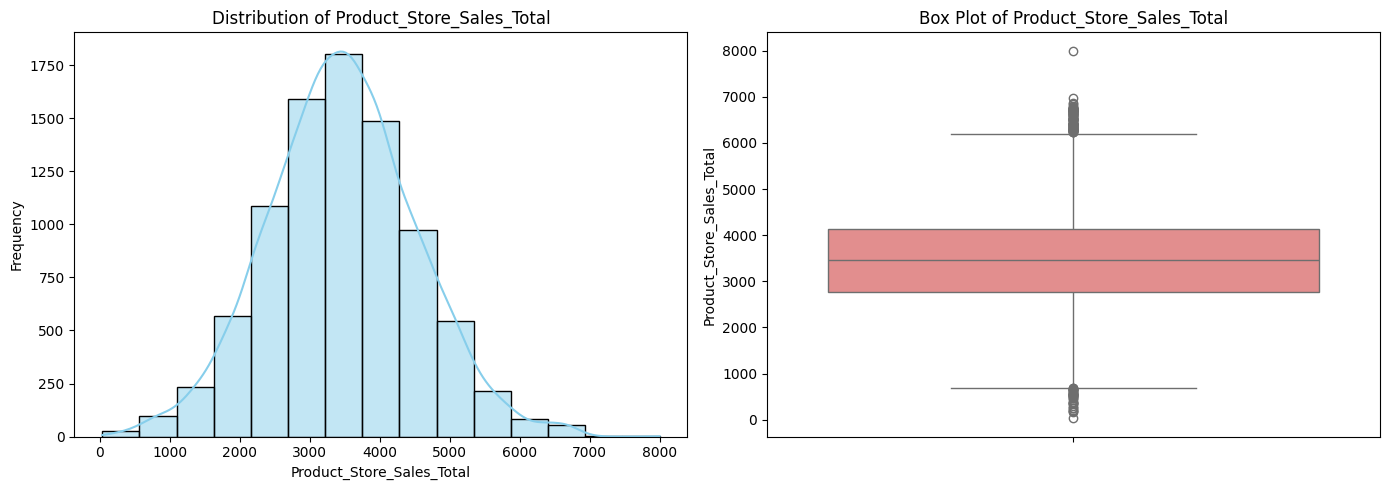



### Univariate Analysis: Categorical Variables ###

--- Value Counts for Product_Sugar_Content ---
Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64




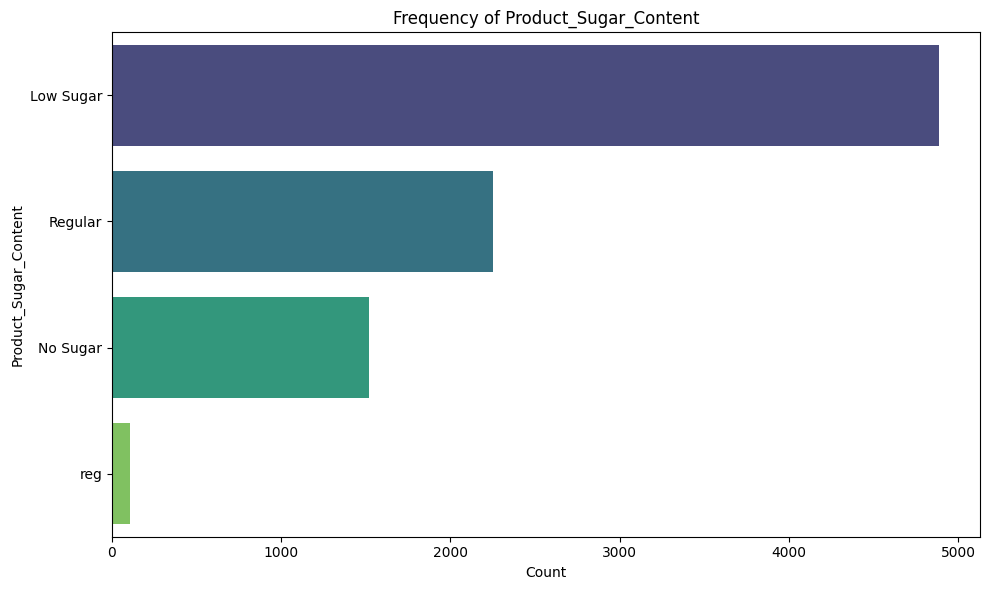



--- Value Counts for Product_Type ---
Product_Type
Fruits and Vegetables    1249
Snack Foods              1149
Frozen Foods              811
Dairy                     796
Household                 740
Baking Goods              716
Canned                    677
Health and Hygiene        628
Meat                      618
Soft Drinks               519
Breads                    200
Hard Drinks               186
Others                    151
Starchy Foods             141
Breakfast                 106
Seafood                    76
Name: count, dtype: int64




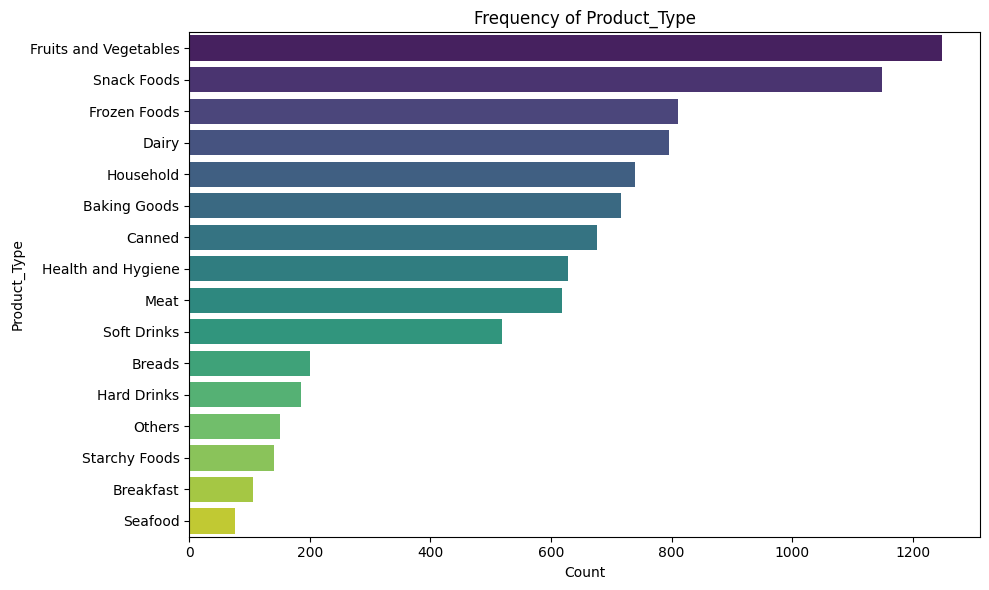



--- Value Counts for Store_Size ---
Store_Size
Medium    6025
High      1586
Small     1152
Name: count, dtype: int64




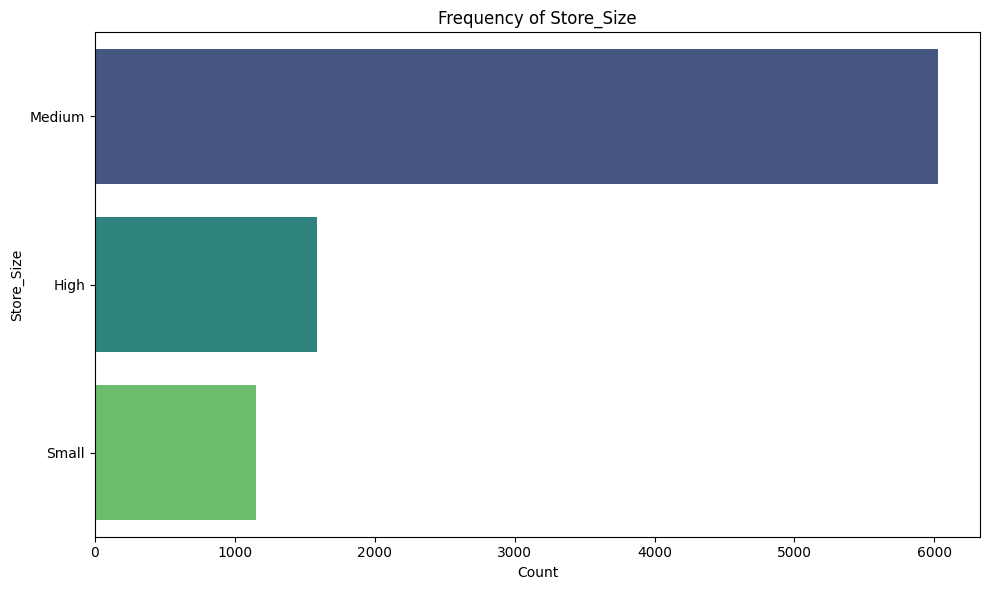



--- Value Counts for Store_Location_City_Type ---
Store_Location_City_Type
Tier 2    6262
Tier 1    1349
Tier 3    1152
Name: count, dtype: int64




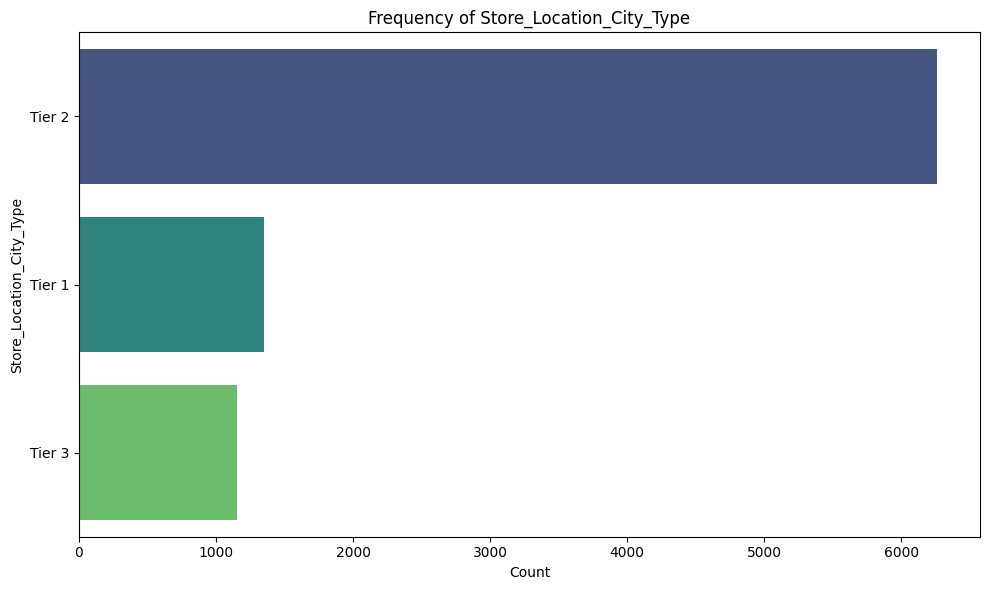



--- Value Counts for Store_Type ---
Store_Type
Supermarket Type2     4676
Supermarket Type1     1586
Departmental Store    1349
Food Mart             1152
Name: count, dtype: int64




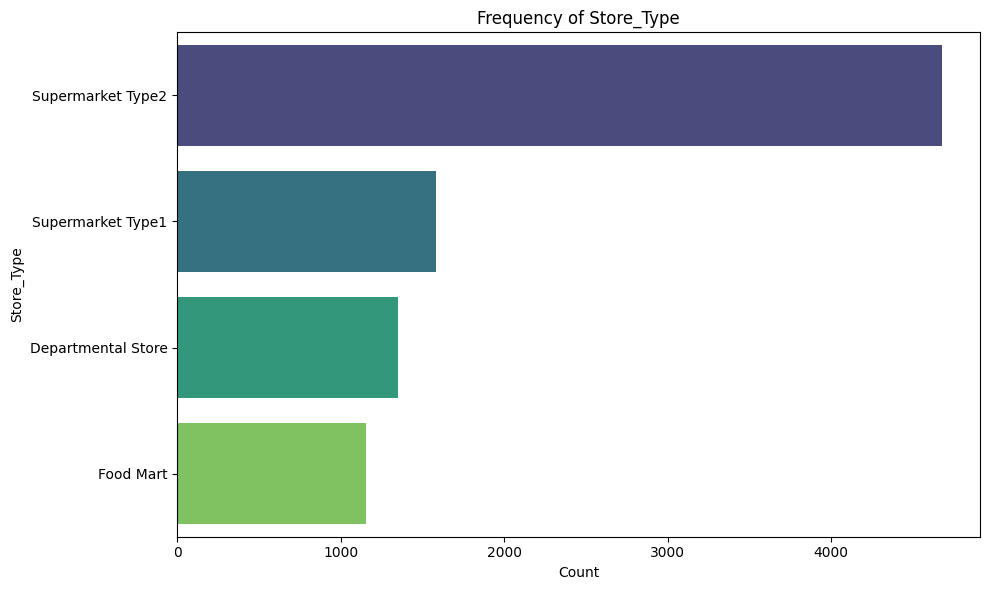



--- Unique Values and Counts for Store_Establishment_Year ---
Store_Establishment_Year
1987    1586
1998    1152
1999    1349
2009    4676
Name: count, dtype: int64


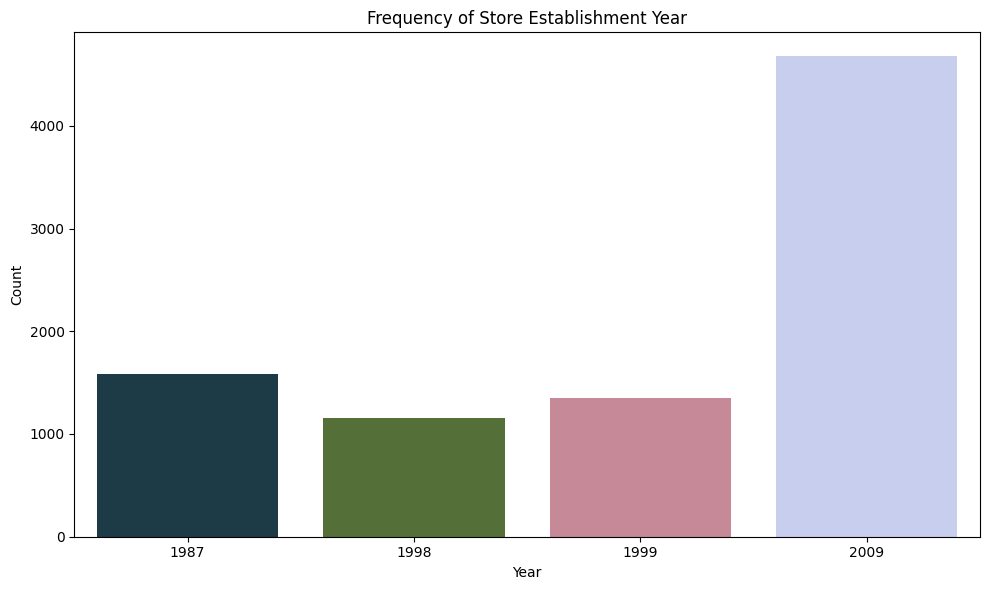

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

# --- 2. Univariate Analysis ---
print("\n### Univariate Analysis ###\n")

# Separate numerical and categorical columns
numerical_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data.select_dtypes(include='object').columns.tolist()

# Exclude 'Product_Id' and 'Store_Id' from typical categorical plotting
# as they are identifiers and often have too many unique values for bar plots.
if 'Product_Id' in categorical_cols:
    categorical_cols.remove('Product_Id')
if 'Store_Id' in categorical_cols:
    categorical_cols.remove('Store_Id')

print(f"Numerical Columns for Analysis: {numerical_cols}")
print(f"Categorical Columns for Analysis: {categorical_cols}")
print("\n" + "="*50 + "\n")

# Univariate Analysis for Numerical Variables
print("### Univariate Analysis: Numerical Variables ###\n")

# Descriptive Statistics
print("--- Descriptive Statistics for Numerical Columns ---")
print(data[numerical_cols].describe())
print("\n" + "="*50 + "\n")

# Histograms and Box Plots for Numerical Variables
for col in numerical_cols:
    plt.figure(figsize=(14, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(data[col], kde=True, bins=15, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Box Plot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=data[col], color='lightcoral')
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

# Univariate Analysis for Categorical Variables
print("### Univariate Analysis: Categorical Variables ###\n")

for col in categorical_cols:
    print(f"--- Value Counts for {col} ---")
    print(data[col].value_counts())
    print("\n")

    plt.figure(figsize=(10, 6))
    sns.countplot(y=data[col], order=data[col].value_counts().index, palette='viridis')
    plt.title(f'Frequency of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

# Special case for Store_Establishment_Year - checking unique values
# Assuming 'Store_Establishment_Year' is in numerical_cols and you want to see its distribution as categories too
if 'Store_Establishment_Year' in numerical_cols:
    print("--- Unique Values and Counts for Store_Establishment_Year ---")
    print(data['Store_Establishment_Year'].value_counts().sort_index())
    plt.figure(figsize=(10, 6))
    sns.countplot(x=data['Store_Establishment_Year'], palette='cubehelix')
    plt.title('Frequency of Store Establishment Year')
    plt.xlabel('Year')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

## Bivariate Analysis

Numerical Columns for Bivariate Analysis (excluding target): ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']
Categorical Columns for Bivariate Analysis: ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']
Target Variable: Product_Store_Sales_Total



### Bivariate Analysis ###

--- 1.1 Correlation Matrix of Numerical Variables ---


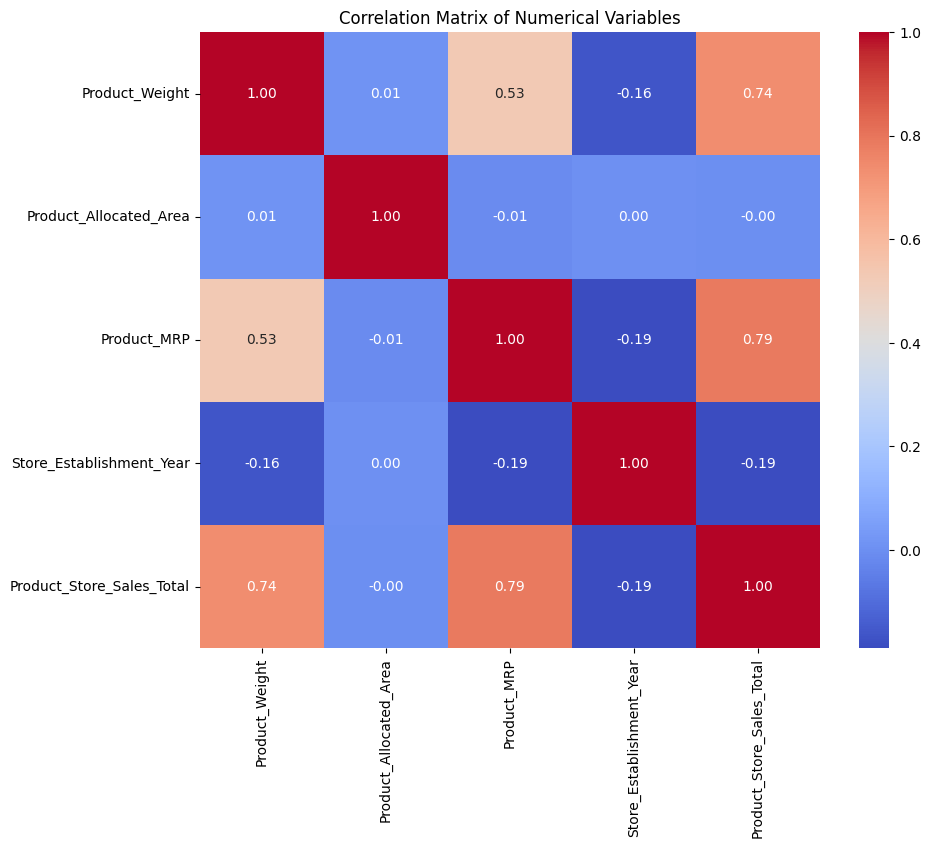



--- 1.2 Scatter Plots of Numerical Features vs. Product_Store_Sales_Total ---


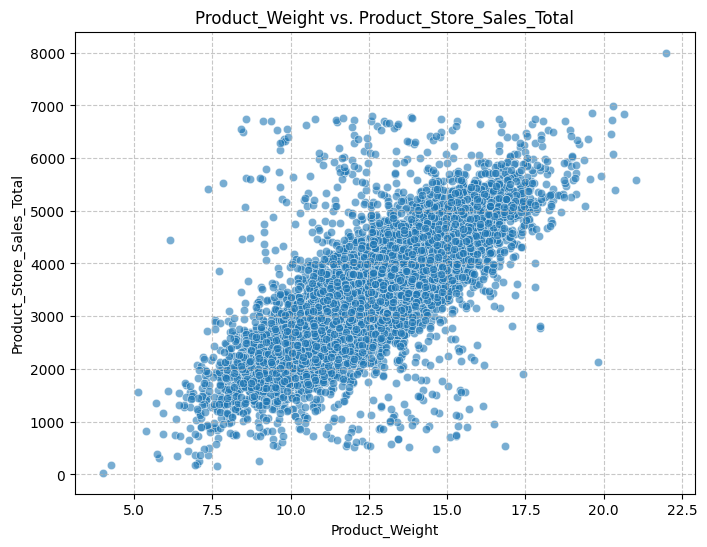

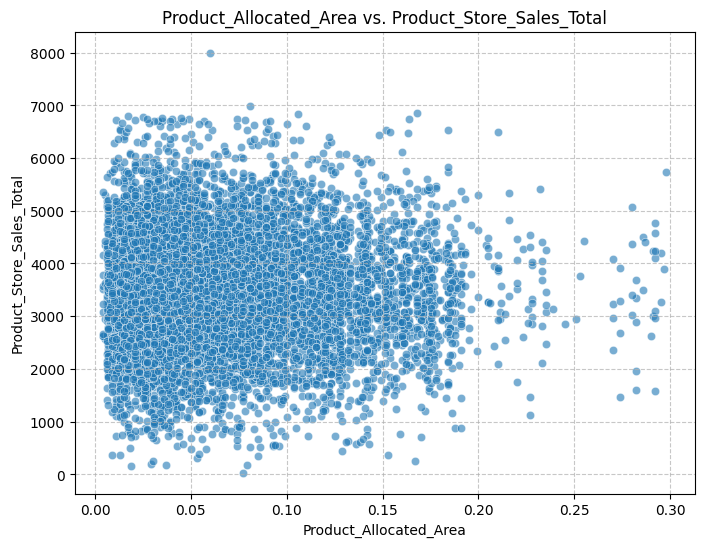

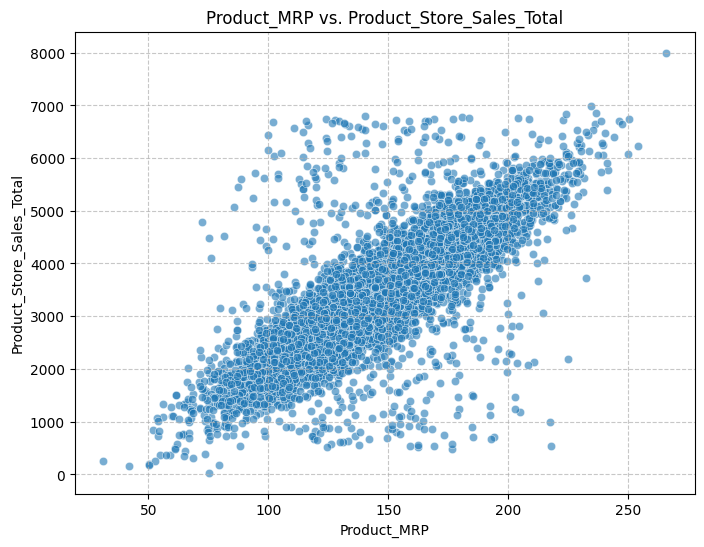

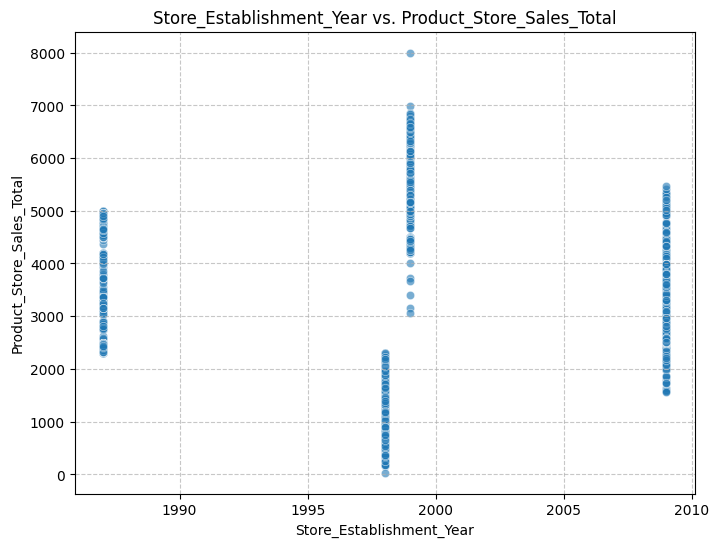



--- 2.1 Box Plots of Categorical Features vs. Product_Store_Sales_Total ---


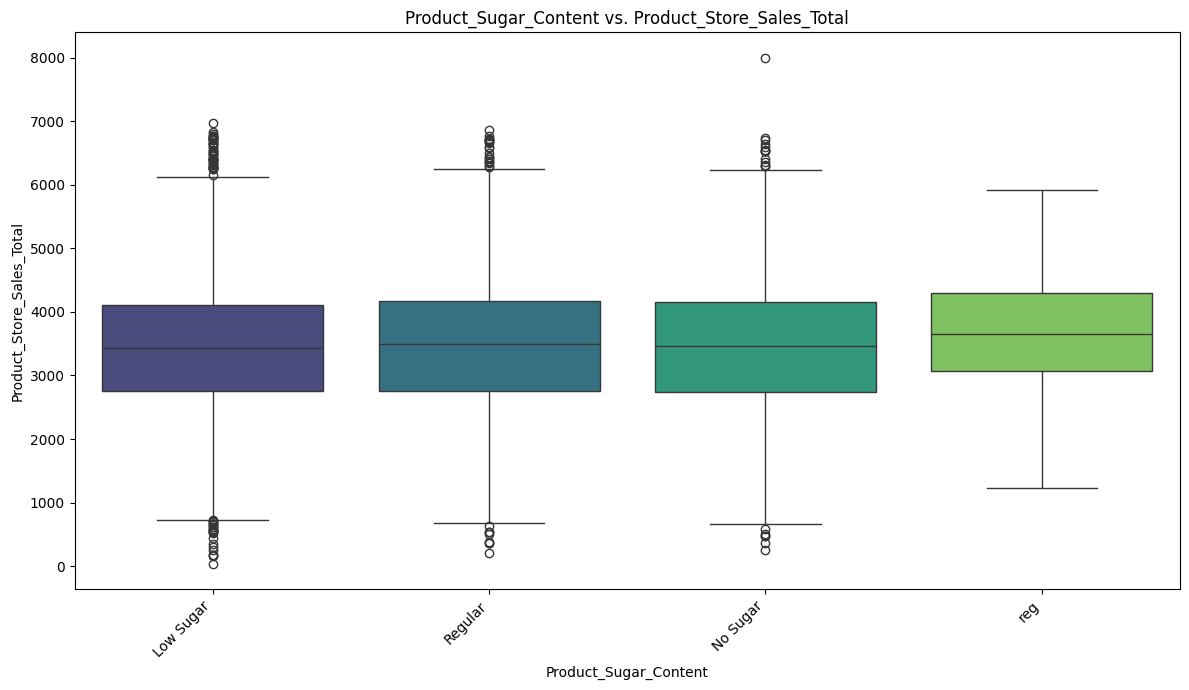

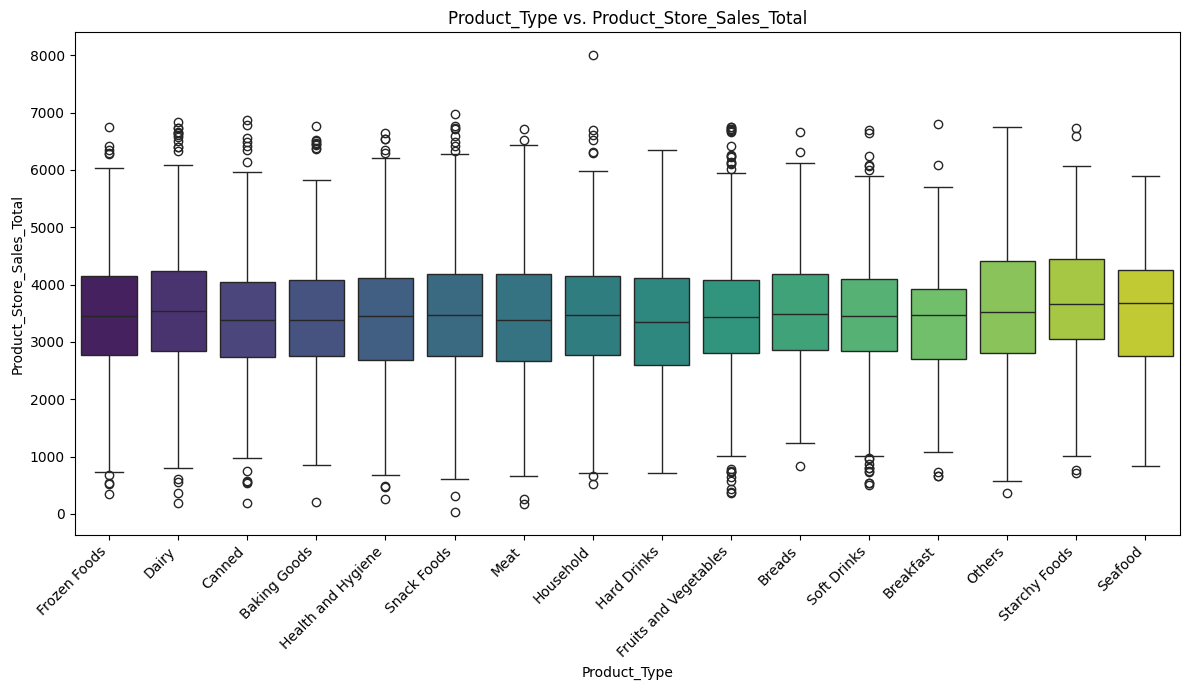

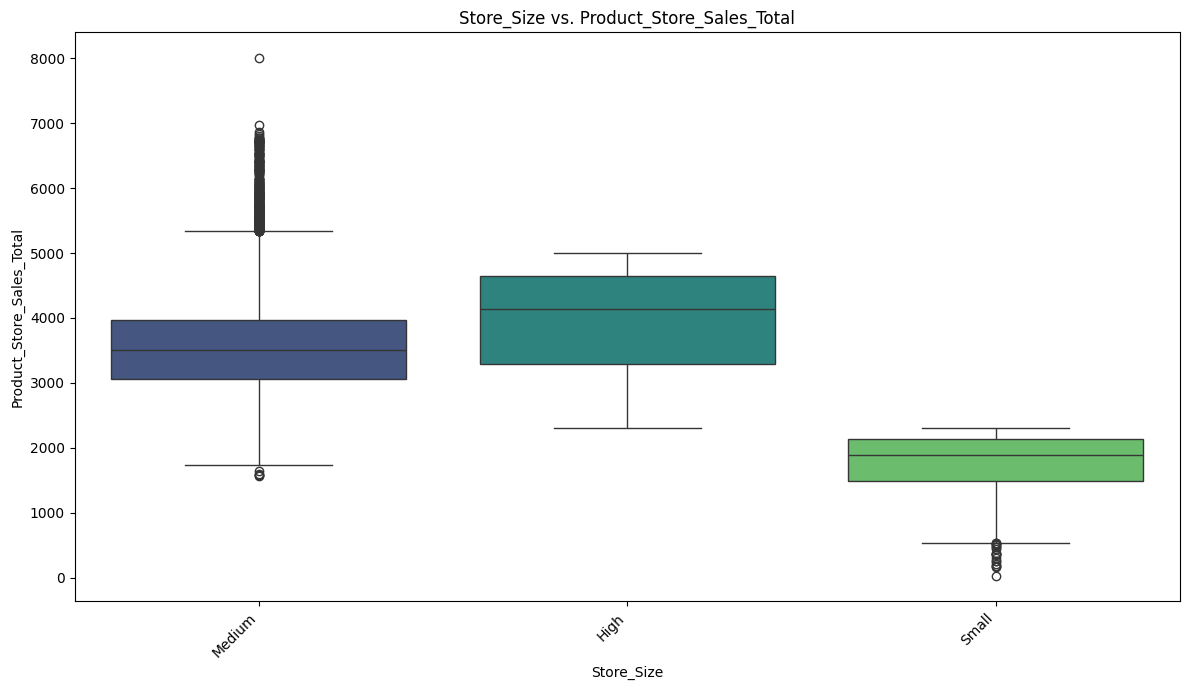

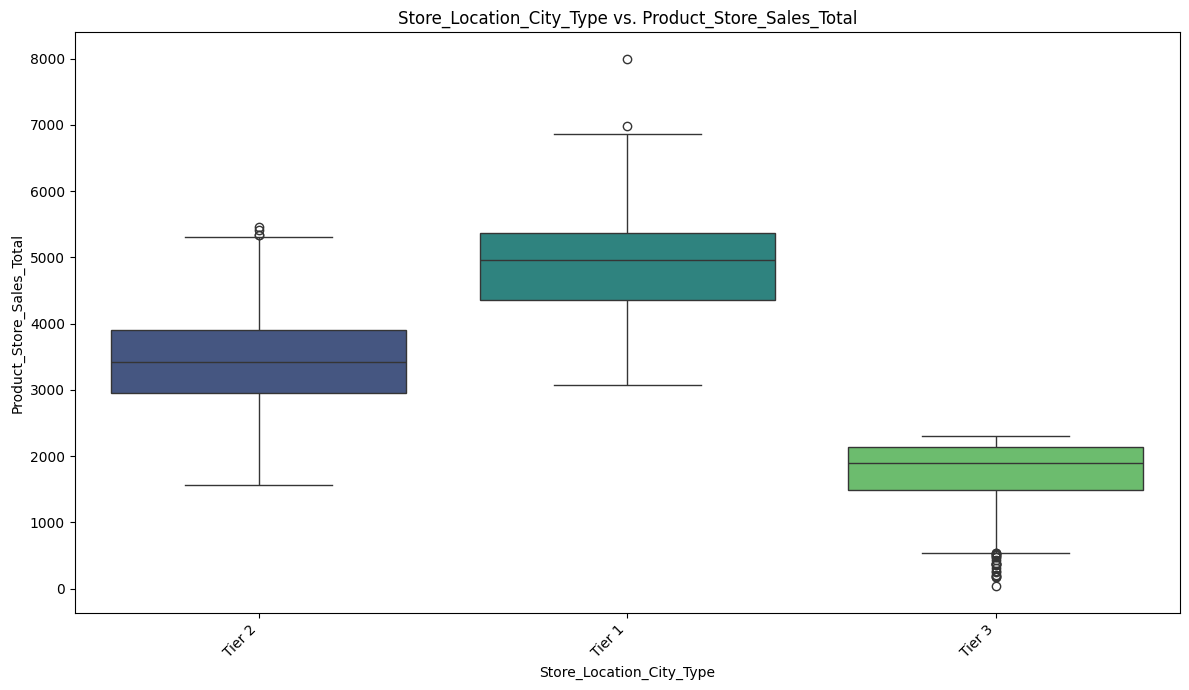

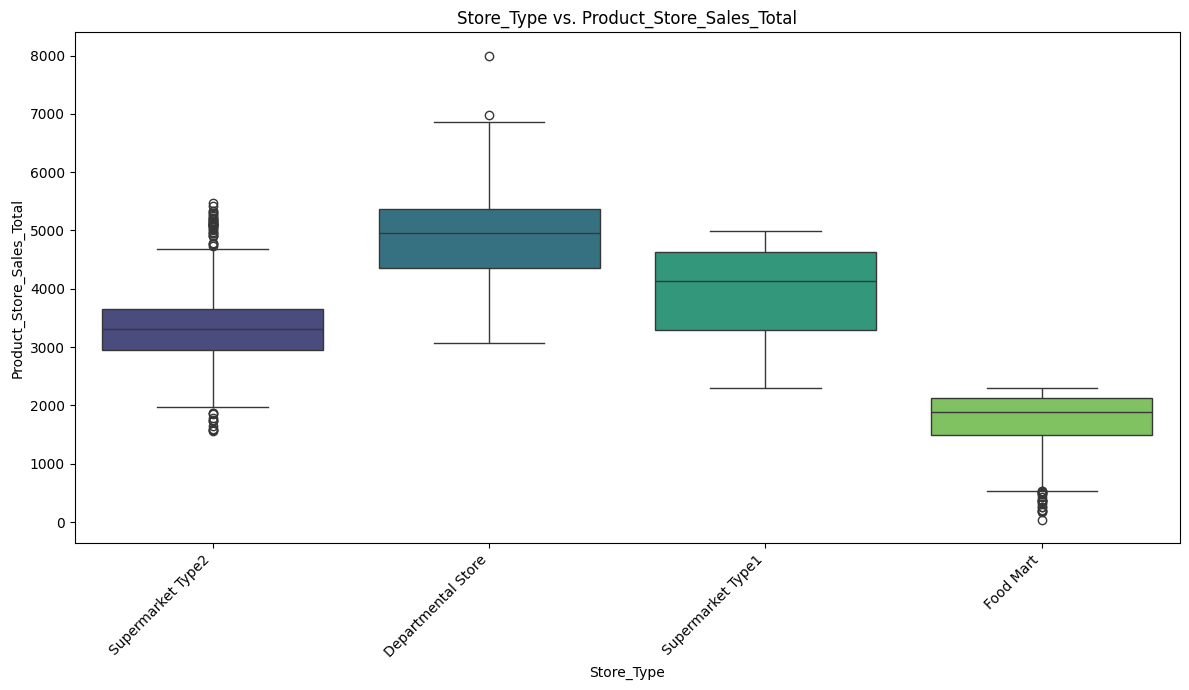



--- 2.2 Bar Plots of Mean Product_Store_Sales_Total by Categorical Features ---


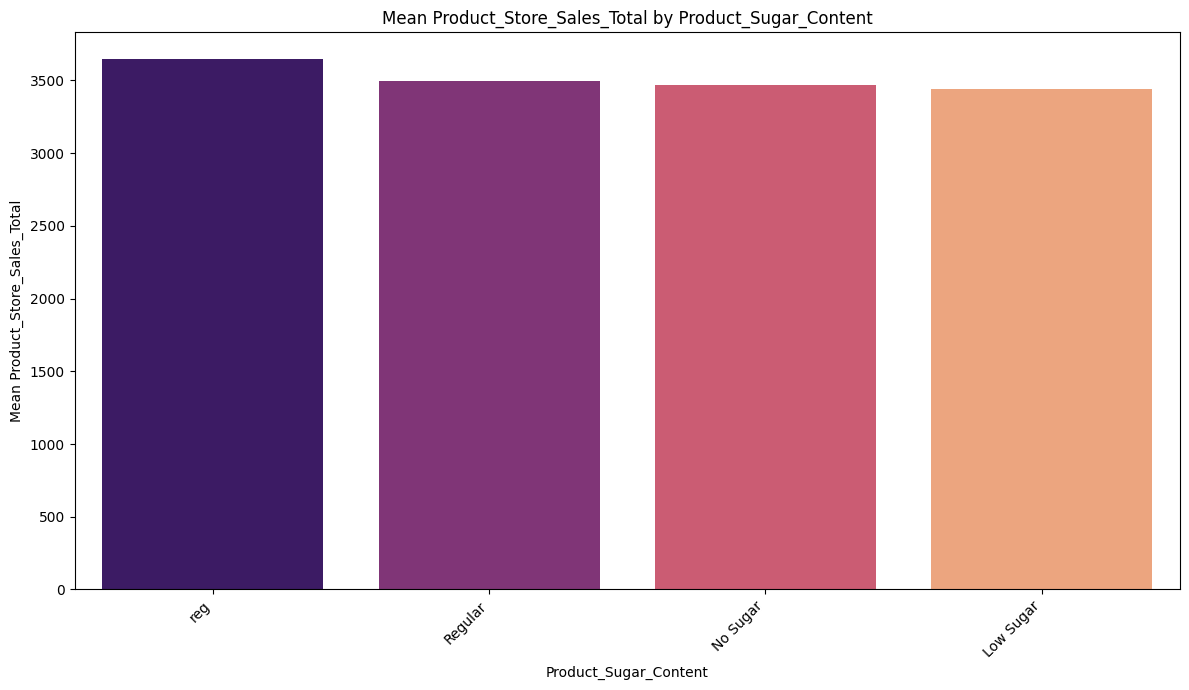

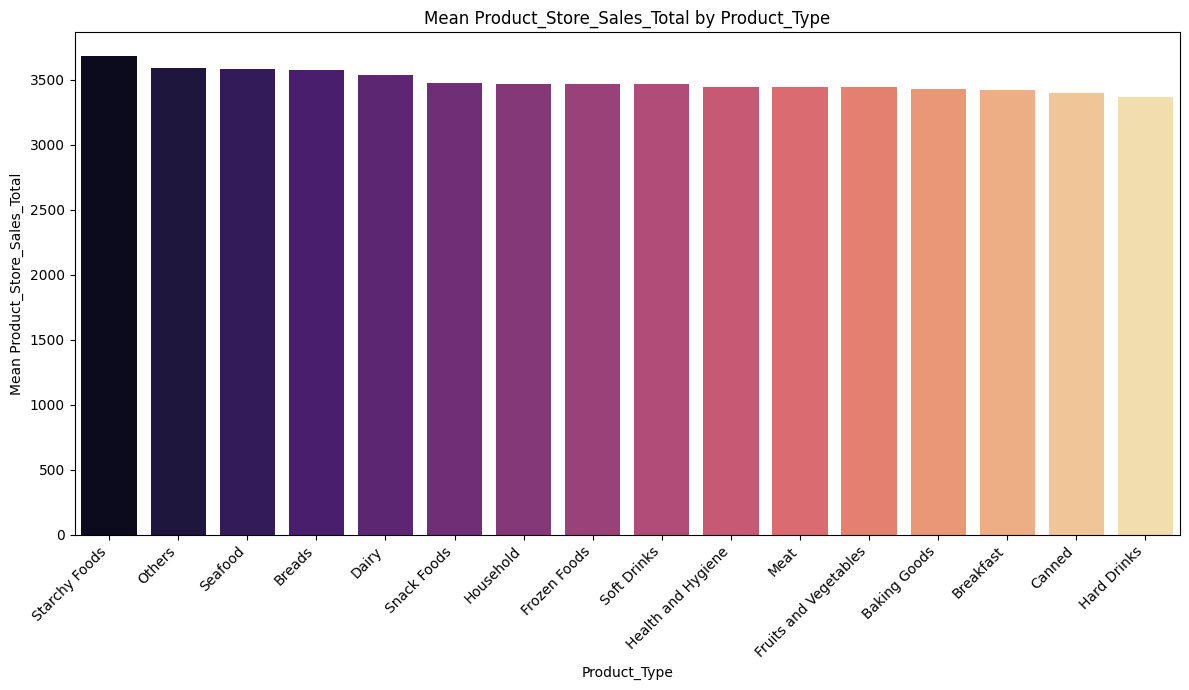

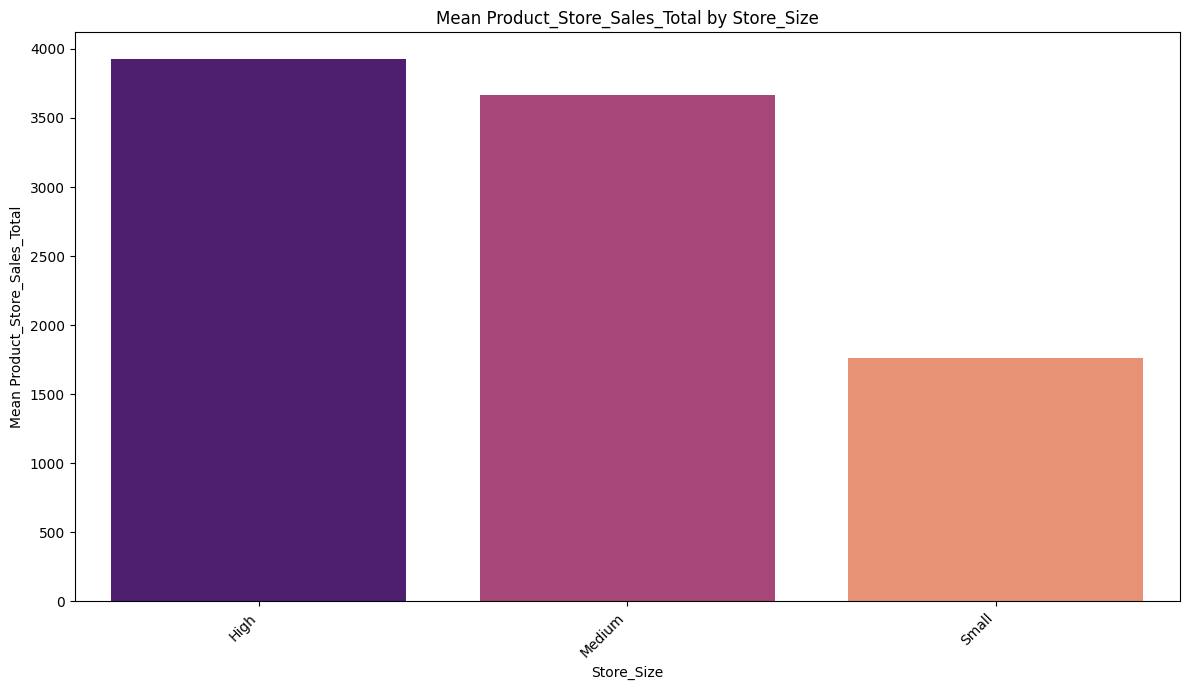

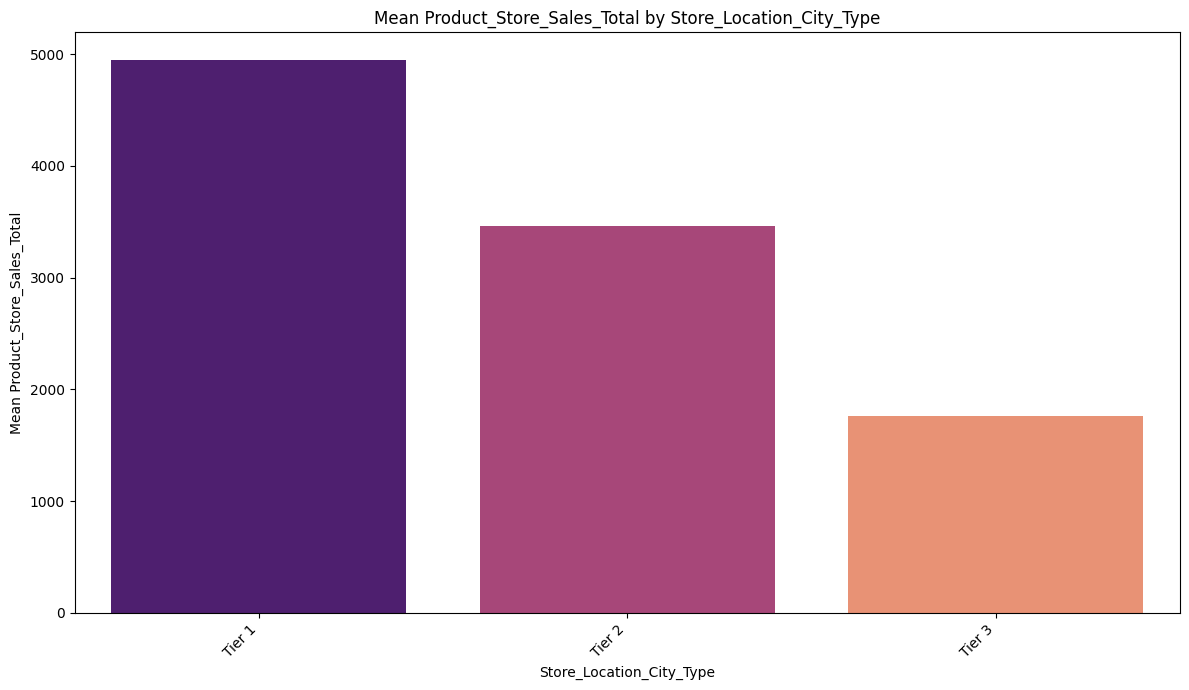

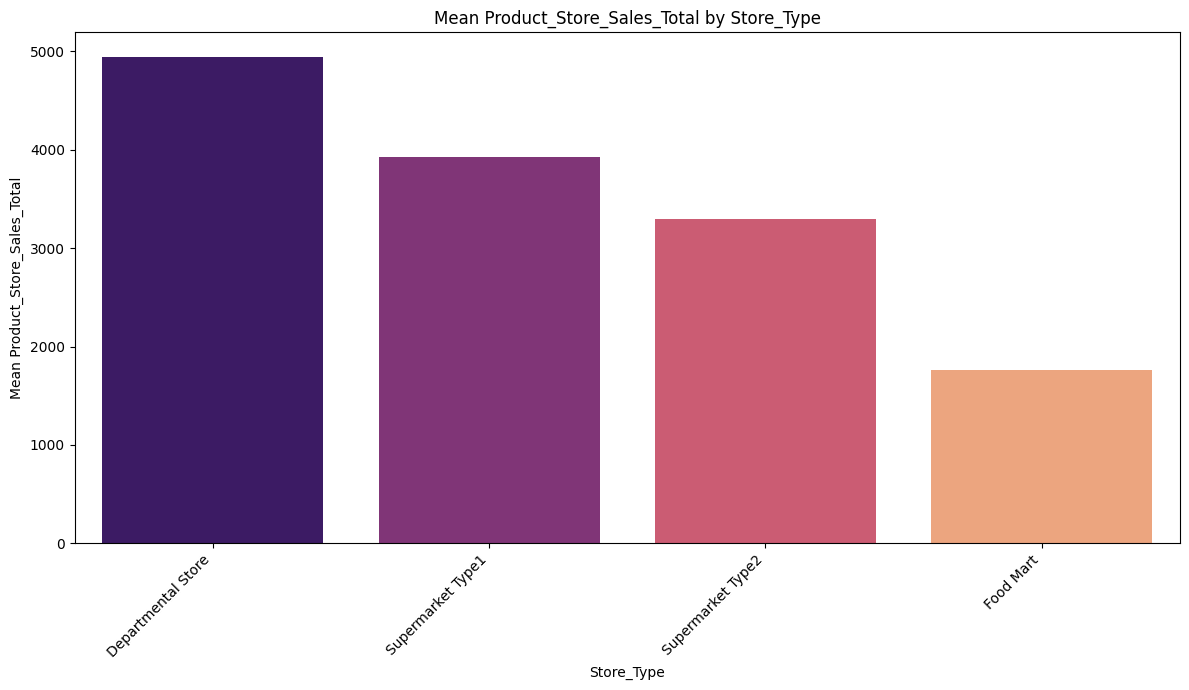



--- 3.1 Cross-Tabulations and Stacked Bar Plots for Selected Categorical Pairs ---

--- Cross-tabulation: Store_Type vs. Store_Location_City_Type ---
Store_Location_City_Type  Tier 1  Tier 2  Tier 3
Store_Type                                      
Departmental Store          1349       0       0
Food Mart                      0       0    1152
Supermarket Type1              0    1586       0
Supermarket Type2              0    4676       0


<Figure size 1000x700 with 0 Axes>

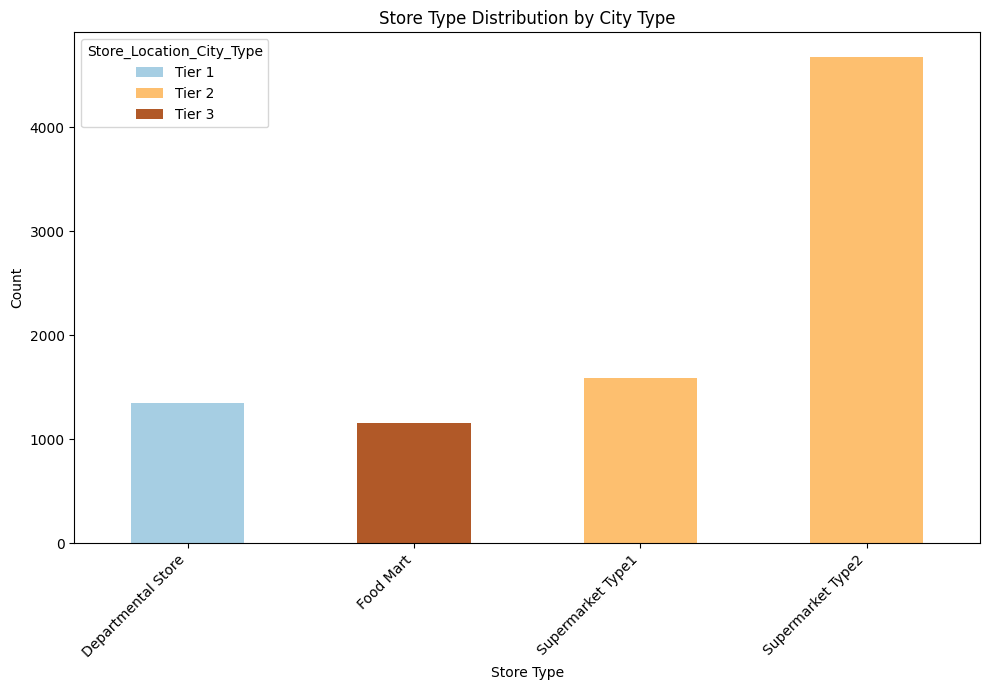




--- Stacked Bar Plot: Product_Sugar_Content by Top 5 Product_Type ---
Product_Sugar_Content  Low Sugar  No Sugar  Regular  reg
Product_Type                                            
Dairy                        590         0      199    7
Frozen Foods                 531         0      264   16
Fruits and Vegetables        864         0      372   13
Household                      0       740        0    0
Snack Foods                  804         0      334   11


<Figure size 1200x700 with 0 Axes>

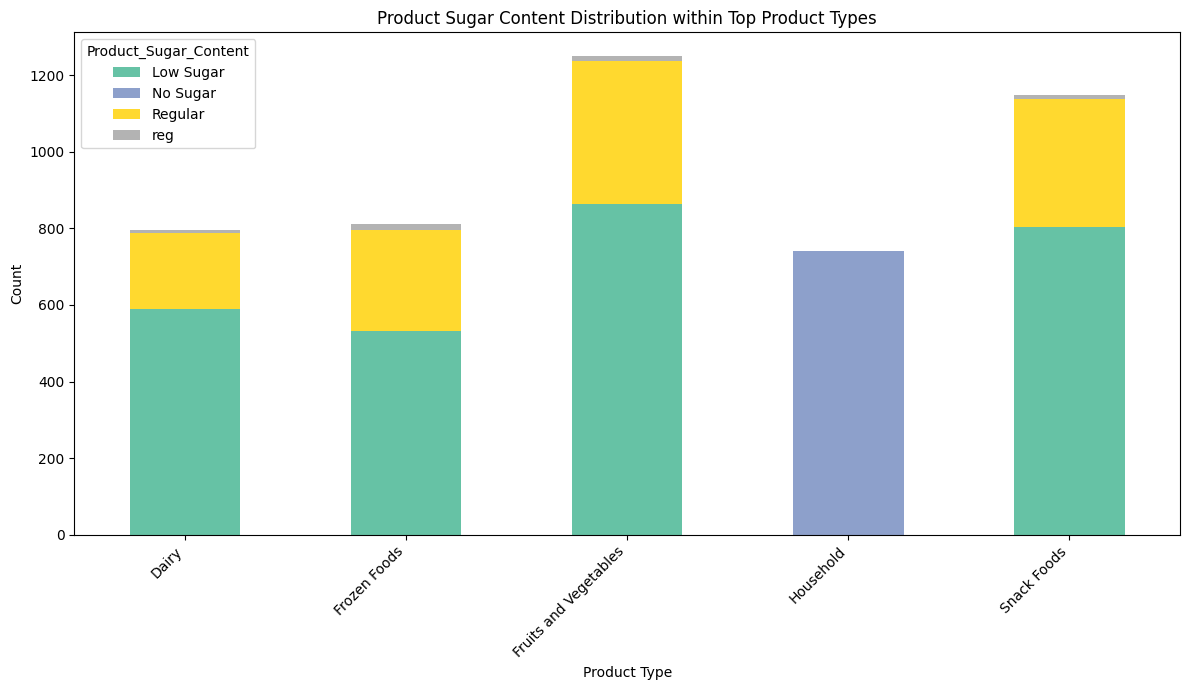




Bivariate Analysis Complete.


In [8]:
# --- Define Target Variable ---
target_variable = 'Product_Store_Sales_Total'

# --- Separate numerical and categorical columns
numerical_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data.select_dtypes(include='object').columns.tolist()

# Remove ID columns from the plotting list if they exist, as they are not useful for bivariate analysis
if 'Product_Id' in categorical_cols:
    categorical_cols.remove('Product_Id')
if 'Store_Id' in categorical_cols:
    categorical_cols.remove('Store_Id')
if target_variable in numerical_cols:
    numerical_cols_for_bivariate = [col for col in numerical_cols if col != target_variable]
else:
    numerical_cols_for_bivariate = numerical_cols

print(f"Numerical Columns for Bivariate Analysis (excluding target): {numerical_cols_for_bivariate}")
print(f"Categorical Columns for Bivariate Analysis: {categorical_cols}")
print(f"Target Variable: {target_variable}")
print("\n" + "="*50 + "\n")


# --- Bivariate Analysis ---
print("\n### Bivariate Analysis ###\n")

# 1. Numerical vs. Numerical Variables

print("--- 1.1 Correlation Matrix of Numerical Variables ---")
plt.figure(figsize=(10, 8))
sns.heatmap(data[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()
print("\n" + "="*50 + "\n")

print(f"--- 1.2 Scatter Plots of Numerical Features vs. {target_variable} ---")
for col in numerical_cols_for_bivariate:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=data[col], y=data[target_variable], alpha=0.6)
    plt.title(f'{col} vs. {target_variable}')
    plt.xlabel(col)
    plt.ylabel(target_variable)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    print("\n" + "="*50 + "\n")

# 2. Categorical vs. Numerical Variables (Target Variable)

print(f"--- 2.1 Box Plots of Categorical Features vs. {target_variable} ---")
for col in categorical_cols:
    plt.figure(figsize=(12, 7))
    sns.boxplot(x=data[col], y=data[target_variable], palette='viridis')
    plt.title(f'{col} vs. {target_variable}')
    plt.xlabel(col)
    plt.ylabel(target_variable)
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

print(f"--- 2.2 Bar Plots of Mean {target_variable} by Categorical Features ---")
for col in categorical_cols:
    plt.figure(figsize=(12, 7))
    mean_sales = data.groupby(col)[target_variable].mean().sort_values(ascending=False)
    sns.barplot(x=mean_sales.index, y=mean_sales.values, palette='magma')
    plt.title(f'Mean {target_variable} by {col}')
    plt.xlabel(col)
    plt.ylabel(f'Mean {target_variable}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

# 3. Categorical vs. Categorical Variables (Optional, for selected pairs)

print("--- 3.1 Cross-Tabulations and Stacked Bar Plots for Selected Categorical Pairs ---")

# Example: Store_Type vs. Store_Location_City_Type
if 'Store_Type' in categorical_cols and 'Store_Location_City_Type' in categorical_cols:
    print("\n--- Cross-tabulation: Store_Type vs. Store_Location_City_Type ---")
    crosstab_st_slct = pd.crosstab(data['Store_Type'], data['Store_Location_City_Type'])
    print(crosstab_st_slct)

    plt.figure(figsize=(10, 7))
    crosstab_st_slct.plot(kind='bar', stacked=True, colormap='Paired', figsize=(10, 7))
    plt.title('Store Type Distribution by City Type')
    plt.xlabel('Store Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

# Example: Product_Sugar_Content vs. Product_Type (top 5 product types)
if 'Product_Sugar_Content' in categorical_cols and 'Product_Type' in categorical_cols:
    print("\n--- Stacked Bar Plot: Product_Sugar_Content by Top 5 Product_Type ---")
    top_product_types = data['Product_Type'].value_counts().nlargest(5).index
    df_filtered = data[data['Product_Type'].isin(top_product_types)]
    crosstab_psc_pt = pd.crosstab(df_filtered['Product_Type'], df_filtered['Product_Sugar_Content'])
    print(crosstab_psc_pt)

    plt.figure(figsize=(12, 7))
    crosstab_psc_pt.plot(kind='bar', stacked=True, colormap='Set2', figsize=(12, 7))
    plt.title('Product Sugar Content Distribution within Top Product Types')
    plt.xlabel('Product Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

print("\nBivariate Analysis Complete.")

This section explores relationships between pairs of variables in our SuperKart sales data. We're looking at how different factors (like product weight, store size, or city type) might influence each other, and especially how they relate to the total sales revenue. This helps us understand which factors are most important for predicting sales.
---

# **Data Preprocessing**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display


try:
    kart = pd.read_csv('/content/drive/MyDrive/SuperKart.csv')
    data = kart.copy()
    print("Dataset loaded successfully for preprocessing.\n")
except FileNotFoundError:
    print("Error: 'SuperKart.csv' not found. Please ensure the file path is correct.")
    raise

print("### Data Preprocessing ###\n")

# --- Step 1: Handle Missing Values ---
print("--- Handling Missing Values ---")
print("Missing values before handling:")
print(data.isnull().sum()[data.isnull().sum() > 0])

# Impute 'Product_Weight' (numerical) with the mean
if 'Product_Weight' in data.columns and data['Product_Weight'].isnull().any():
    data['Product_Weight'].fillna(data['Product_Weight'].mean(), inplace=True)
    print(f"\n'Product_Weight' missing values imputed with mean: {data['Product_Weight'].mean():.2f}")

# Impute 'Store_Size' (categorical) with the mode
if 'Store_Size' in data.columns and data['Store_Size'].isnull().any():
    mode_store_size = data['Store_Size'].mode()[0]
    data['Store_Size'].fillna(mode_store_size, inplace=True)
    print(f"'Store_Size' missing values imputed with mode: '{mode_store_size}'")

# Impute 'Product_Allocated_Area' (numerical) with the mean
# Assuming 0.00 is a valid value for no allocated area, but if NaN, impute.
if 'Product_Allocated_Area' in data.columns and data['Product_Allocated_Area'].isnull().any():
    data['Product_Allocated_Area'].fillna(data['Product_Allocated_Area'].mean(), inplace=True)
    print(f"'Product_Allocated_Area' missing values imputed with mean: {data['Product_Allocated_Area'].mean():.4f}")


print("\nMissing values after handling:")
print(data.isnull().sum()[data.isnull().sum() > 0]) # Should show no missing values now for these columns
if data.isnull().sum().sum() == 0:
    print("No missing values remaining in the dataset.")
print("\n" + "="*50 + "\n")


# --- Step 2: Correct Inconsistent Data Entries (Categorical Features) ---
print("--- Correcting Inconsistent Categorical Data ---")

# Standardize 'Product_Sugar_Content'
if 'Product_Sugar_Content' in data.columns:
    print("\nOriginal 'Product_Sugar_Content' value counts:")
    print(data['Product_Sugar_Content'].value_counts())
    data['Product_Sugar_Content'] = data['Product_Sugar_Content'].replace('reg', 'Regular')
    print("\nCorrected 'Product_Sugar_Content' value counts:")
    print(data['Product_Sugar_Content'].value_counts())

# Standardize 'Product_Type'
if 'Product_Type' in data.columns:
    print("\nOriginal 'Product_Type' value counts (top 10 before correction):")
    print(data['Product_Type'].value_counts().head(10))
    product_type_mapping = {
        'Frozen Fo': 'Frozen Foods',
        'Health an': 'Health and Hygiene',
        'Hard Drinl': 'Hard Drinks',
        'Househol': 'Household',
        'Snack Foc': 'Snack Foods',
        'Starchy Fo': 'Starchy Foods',
        'Fruits and': 'Fruits and Vegetables',
        'Supermar': 'Supermarket Type1',
        'Departme': 'Departmental Store',
        'Food Mart': 'Food Mart',
        'Baking Go': 'Baking Goods',
        'Frozen Fou': 'Frozen Foods'
    }
    data['Product_Type'] = data['Product_Type'].replace(product_type_mapping)
    print("\nCorrected 'Product_Type' value counts (top 10 after correction):")
    print(data['Product_Type'].value_counts().head(10))

# Standardize 'Store_Type'
if 'Store_Type' in data.columns:
    print("\nOriginal 'Store_Type' value counts:")
    print(data['Store_Type'].value_counts())
    store_type_mapping = {
        'Supermar': 'Supermarket Type1', # Assuming Supermar refers to Supermarket Type1
        'Departme': 'Departmental Store',
        'Food Mart': 'Food Mart'
        # Add other specific mappings if 'Supermarket Type 2' is also truncated differently
    }
    data['Store_Type'] = data['Store_Type'].replace(store_type_mapping)
    print("\nCorrected 'Store_Type' value counts:")
    print(data['Store_Type'].value_counts())

print("\n" + "="*50 + "\n")


# --- Step 3: Feature Engineering ---
print("--- Feature Engineering ---")

# Create 'Store_Age'
if 'Store_Establishment_Year' in data.columns:
    current_year = 2025 # As per current time context
    data['Store_Age'] = current_year - data['Store_Establishment_Year']
    print(f"\n'Store_Age' created. Max Age: {data['Store_Age'].max()}, Min Age: {data['Store_Age'].min()}")
    print("First 5 rows with 'Store_Age':")
    display(data[['Store_Establishment_Year', 'Store_Age']].head())

# Extract 'Product_Broad_Category' from 'Product_Id'
if 'Product_Id' in data.columns:
    data['Product_Broad_Category'] = data['Product_Id'].apply(lambda x: x[:2])
    print("\n'Product_Broad_Category' created from 'Product_Id'.")
    print("Value counts for 'Product_Broad_Category':")
    print(data['Product_Broad_Category'].value_counts())
    print("First 5 rows with 'Product_Broad_Category':")
    display(data[['Product_Id', 'Product_Broad_Category']].head())

print("\n" + "="*50 + "\n")

print("Data Preprocessing Complete. Displaying head of processed data:")
display(data.head())
print("\nInfo of processed data:")
data.info()

Dataset loaded successfully for preprocessing.

### Data Preprocessing ###

--- Handling Missing Values ---
Missing values before handling:
Series([], dtype: int64)

Missing values after handling:
Series([], dtype: int64)
No missing values remaining in the dataset.


--- Correcting Inconsistent Categorical Data ---

Original 'Product_Sugar_Content' value counts:
Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64

Corrected 'Product_Sugar_Content' value counts:
Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64

Original 'Product_Type' value counts (top 10 before correction):
Product_Type
Fruits and Vegetables    1249
Snack Foods              1149
Frozen Foods              811
Dairy                     796
Household                 740
Baking Goods              716
Canned                    677
Health and Hygiene        628
Meat                      618
Soft Drinks    

,Store_Establishment_Year,Store_Age
0,2009,16
1,1999,26
2,1987,38
3,1987,38
4,1998,27



'Product_Broad_Category' created from 'Product_Id'.
Value counts for 'Product_Broad_Category':
Product_Broad_Category
FD    6539
NC    1519
DR     705
Name: count, dtype: int64
First 5 rows with 'Product_Broad_Category':


,Product_Id,Product_Broad_Category
0,FD6114,FD
1,FD7839,FD
2,FD5075,FD
3,FD8233,FD
4,NC1180,NC




Data Preprocessing Complete. Displaying head of processed data:


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age,Product_Broad_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,16,FD
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,26,FD
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,38,FD
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,38,FD
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,27,NC



Info of processed data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
 12  Store_Age                  8763 non-null   int64  
 13  Product_Broad_Category 

Handling Missing Values:

We first print the sum of null values for each column to clearly see what needs to be addressed.
Product_Weight: This is a numerical feature. A common strategy is to impute missing values with the mean of the existing values, which is done here.
Store_Size: This is a categorical feature. We impute missing values with the mode (the most frequent category) to maintain the distribution as much as possible.
Product_Allocated_Area: Similar to Product_Weight, missing numerical values are imputed with the mean.
Correcting Inconsistent Categorical Data:

Product_Sugar_Content: Based on your sample, 'reg' is a shorthand for 'Regular'. This is corrected using the .replace() method.
Product_Type: The OCR showed several truncated product types (e.g., "Frozen Fo", "Health an"). I've created a dictionary (product_type_mapping) to map these truncated forms to their full, consistent names as per your data description.
Store_Type: Similarly, "Supermar" and "Departme" are mapped to "Supermarket Type1" and "Departmental Store" respectively.
Feature Engineering:

Store_Age: This new numerical feature is calculated by subtracting the Store_Establishment_Year from the current_year (set to 2025 for this analysis). This gives a more intuitive measure of how old each store is, which could be a significant factor in sales forecasting.
Product_Broad_Category: From the Product_Id (e.g., 'FD6114', 'NC1180'), the first two letters seem to indicate a broader category. This feature extracts those two letters, potentially grouping products into types like 'FD', 'NC', 'DR', etc., which might be useful for analysis.

# **Model Building**

## Define functions for Model Evaluation

In [10]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [11]:


# --- Model Building Setup ---
print("### Model Building Setup ###\n")

# Define features (X) and target (y)
# Drop original ID and Year columns, as 'Product_Broad_Category' and 'Store_Age' are engineered features
X = data.drop(['Product_Store_Sales_Total', 'Product_Id', 'Store_Id', 'Store_Establishment_Year'], axis=1)
y = data['Product_Store_Sales_Total']

# Identify numerical and categorical columns for preprocessing within the pipeline
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f"Features used for modeling: {X.columns.tolist()}")
print(f"Numerical features for scaling: {numerical_features}")
print(f"Categorical features for one-hot encoding: {categorical_features}")
print(f"Target variable: {y.name}")
print("\n" + "="*50 + "\n")

# Create preprocessing ColumnTransformer
# This transformer will be part of each model's pipeline to prevent data leakage.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split the data into training and testing sets (using a fixed random_state for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Data split into training ({len(X_train)} samples) and testing ({len(X_test)} samples) sets.\n")
print("\n" + "="*50 + "\n")


# --- Model 1: XGBoost Regressor ---
print("### Model 1: XGBoost Regressor ###\n")

# Create the full pipeline with preprocessing and XGBoost Regressor model
xgboost_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                       ('regressor', xgb.XGBRegressor(random_state=42))])

print("Training XGBoost Regressor model...")
xgboost_reg_pipeline.fit(X_train, y_train)
print("XGBoost Model training complete.\n")

# Evaluate XGBoost Model performance on the training set
print("XGBoost Regressor - Training Set Performance:")
xgb_train_perf = model_performance_regression(xgboost_reg_pipeline, X_train, y_train)
display(xgb_train_perf)

# Evaluate XGBoost Model performance on the test set
print("\nXGBoost Regressor - Test Set Performance:")
xgb_test_perf = model_performance_regression(xgboost_reg_pipeline, X_test, y_test)
display(xgb_test_perf)
print("\n" + "="*50 + "\n")


# --- Model 2: Random Forest Regressor ---
print("### Model 2: Random Forest Regressor ###\n")

# Create the full pipeline with preprocessing and Random Forest Regressor model
random_forest_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                            ('regressor', RandomForestRegressor(random_state=42))])

print("Training Random Forest Regressor model...")
random_forest_reg_pipeline.fit(X_train, y_train)
print("Random Forest Model training complete.\n")

# Evaluate Random Forest Model performance on the training set
print("Random Forest Regressor - Training Set Performance:")
rf_train_perf = model_performance_regression(random_forest_reg_pipeline, X_train, y_train)
display(rf_train_perf)

# Evaluate Random Forest Model performance on the test set
print("\nRandom Forest Regressor - Test Set Performance:")
rf_test_perf = model_performance_regression(random_forest_reg_pipeline, X_test, y_test)
display(rf_test_perf)
print("\n" + "="*50 + "\n")

print("Both XGBoost and Random Forest models have been built and evaluated. Ready for comparison and tuning!")

### Model Building Setup ###

Features used for modeling: ['Product_Weight', 'Product_Sugar_Content', 'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Store_Age', 'Product_Broad_Category']
Numerical features for scaling: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age']
Categorical features for one-hot encoding: ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Broad_Category']
Target variable: Product_Store_Sales_Total


Data split into training (7010 samples) and testing (1753 samples) sets.



### Model 1: XGBoost Regressor ###

Training XGBoost Regressor model...
XGBoost Model training complete.

XGBoost Regressor - Training Set Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,131.819808,62.793739,0.984677,0.984656,0.022454



XGBoost Regressor - Test Set Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,307.420031,138.251943,0.917173,0.916698,0.051184




### Model 2: Random Forest Regressor ###

Training Random Forest Regressor model...
Random Forest Model training complete.

Random Forest Regressor - Training Set Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,106.941311,40.374899,0.989915,0.989901,0.015185



Random Forest Regressor - Test Set Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,284.459587,109.242219,0.929083,0.928676,0.03897




Both XGBoost and Random Forest models have been built and evaluated. Ready for comparison and tuning!


# **Model Performance Improvement - Hyperparameter Tuning**

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline # Using make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display



# Function to compute Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Handle cases where y_true might be zero to avoid division by zero
    y_true_safe = np.where(y_true == 0, np.finfo(float).eps, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100

# Function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    if (n - k - 1) <= 0: # Handle cases where denominator might be zero or negative
        return r2 # Fallback to regular R2 if adjusted R2 cannot be meaningfully computed
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: trained scikit-learn pipeline (regressor)
    predictors: independent variables (DataFrame or array-like)
    target: dependent variable (Series or array-like)
    """
    pred = model.predict(predictors)

    # When using make_pipeline, a ColumnTransformer step is typically named 'columntransformer'.
    # This assumes your ColumnTransformer is the first step after make_pipeline and is not explicitly renamed.
    transformed_predictors = model.named_steps['columntransformer'].transform(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(transformed_predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )
    return df_perf

print("Corrected helper functions for model evaluation defined.\n")

# --- Hyperparameter Tuning Portion ---
# Assumes X_train, X_test, y_train, y_test, and the 'preprocessor' ColumnTransformer
# are already defined and available from your previous data preparation steps.

# Define the scorer to be used by GridSearchCV (minimizing RMSE)
rmse_scorer = make_scorer(lambda y_true, y_pred: -np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=True)

print("### Hyperparameter Tuning ###\n")

# --- Model 1: XGBoost Regressor Hyperparameter Tuning ---
print("--- Tuning XGBoost Regressor ---")

# Choose the type of regressor and create a pipeline with the preprocessor
xgb_pipeline_for_tuning = make_pipeline(preprocessor, xgb.XGBRegressor(random_state=42))

# Grid of parameters to choose from
# Reduced grid to address potential NaN issues and speed up initial run
parameters_xgb = {
    "xgbregressor__n_estimators": [100, 200],
    "xgbregressor__learning_rate": [0.05, 0.1],
    "xgbregressor__max_depth": [3, 5],
    "xgbregressor__subsample": [0.8], # Fixed for now
    "xgbregressor__colsample_bytree": [0.8], # Fixed for now
    "xgbregressor__gamma": [0, 0.1]
}

# Run the grid search
print("\nStarting GridSearchCV for XGBoost. This may take a while...")
grid_search_xgb = GridSearchCV(xgb_pipeline_for_tuning, parameters_xgb, scoring=rmse_scorer, cv=3, n_jobs=-1, verbose=1)
grid_search_xgb.fit(X_train, y_train)

# Set the best model
best_xgboost_model_tuned = grid_search_xgb.best_estimator_

print("\nXGBoost Tuning Complete.")
print("Best hyperparameters for XGBoost:", grid_search_xgb.best_params_)
print(f"Best cross-validation RMSE for XGBoost: ${-grid_search_xgb.best_score_:.2f}")

# Evaluate the best XGBoost model on the training set
print("\nBest XGBoost Regressor - Tuned Training Set Performance:")
xgb_tuned_train_perf = model_performance_regression(best_xgboost_model_tuned, X_train, y_train)
display(xgb_tuned_train_perf)

# Evaluate the best XGBoost model on the test set
print("\nBest XGBoost Regressor - Tuned Test Set Performance:")
xgb_tuned_test_perf = model_performance_regression(best_xgboost_model_tuned, X_test, y_test)
display(xgb_tuned_test_perf)
print("\n" + "="*50 + "\n")


# --- Model 2: Random Forest Regressor Hyperparameter Tuning ---
print("--- Tuning Random Forest Regressor ---")

# Choose the type of regressor and create a pipeline with the preprocessor
rf_pipeline_for_tuning = make_pipeline(preprocessor, RandomForestRegressor(random_state=42))

# Grid of parameters to choose from
# Reduced grid to address potential NaN issues and speed up initial run
parameters_rf = {
    "randomforestregressor__n_estimators": [100, 200],
    "randomforestregressor__max_depth": [5, 10],
    "randomforestregressor__min_samples_split": [2, 5],
    "randomforestregressor__min_samples_leaf": [1, 2],
    "randomforestregressor__max_features": [0.7, 0.9]
}

# Run the grid search
print("\nStarting GridSearchCV for Random Forest. This may take a while...")
grid_search_rf = GridSearchCV(rf_pipeline_for_tuning, parameters_rf, scoring=rmse_scorer, cv=3, n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train)

# Set the best model
best_rf_model_tuned = grid_search_rf.best_estimator_

print("\nRandom Forest Tuning Complete.")
print("Best hyperparameters for Random Forest:", grid_search_rf.best_params_)
print(f"Best cross-validation RMSE for Random Forest: ${-grid_search_rf.best_score_:.2f}")

# Evaluate the best Random Forest model on the training set
print("\nBest Random Forest Regressor - Tuned Training Set Performance:")
rf_tuned_train_perf = model_performance_regression(best_rf_model_tuned, X_train, y_train)
display(rf_tuned_train_perf)

# Evaluate the best Random Forest model on the test set
print("\nBest Random Forest Regressor - Tuned Test Set Performance:")
rf_tuned_test_perf = model_performance_regression(best_rf_model_tuned, X_test, y_test)
display(rf_tuned_test_perf)
print("\n" + "="*50 + "\n")

print("Hyperparameter tuning for both models is complete with the KeyError resolved.")


Corrected helper functions for model evaluation defined.

### Hyperparameter Tuning ###

--- Tuning XGBoost Regressor ---

Starting GridSearchCV for XGBoost. This may take a while...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

XGBoost Tuning Complete.
Best hyperparameters for XGBoost: {'xgbregressor__colsample_bytree': 0.8, 'xgbregressor__gamma': 0, 'xgbregressor__learning_rate': 0.05, 'xgbregressor__max_depth': 5, 'xgbregressor__n_estimators': 200, 'xgbregressor__subsample': 0.8}
Best cross-validation RMSE for XGBoost: $298.69

Best XGBoost Regressor - Tuned Training Set Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,239.611966,98.296293,0.949372,0.949111,3.796134



Best XGBoost Regressor - Tuned Test Set Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,288.800717,122.335477,0.926902,0.925369,4.551911




--- Tuning Random Forest Regressor ---

Starting GridSearchCV for Random Forest. This may take a while...
Fitting 3 folds for each of 32 candidates, totalling 96 fits

Random Forest Tuning Complete.
Best hyperparameters for Random Forest: {'randomforestregressor__max_depth': 10, 'randomforestregressor__max_features': 0.9, 'randomforestregressor__min_samples_leaf': 2, 'randomforestregressor__min_samples_split': 5, 'randomforestregressor__n_estimators': 200}
Best cross-validation RMSE for Random Forest: $286.73

Best Random Forest Regressor - Tuned Training Set Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,213.756872,84.620239,0.959709,0.959501,3.058387



Best Random Forest Regressor - Tuned Test Set Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,278.089968,112.834475,0.932224,0.930802,4.027893




Hyperparameter tuning for both models is complete with the KeyError resolved.


# **Model Performance Comparison, Final Model Selection, and Serialization**

In [13]:

import pandas as pd
import numpy as np
import joblib # For model serialization


# --- Model Performance Comparison ---
print("### Model Performance Comparison ###\n")

# Re-creating the performance DataFrames using the full, consistent index names
# based on the output you provided:

# XGBoost Tuned Performance
xgb_tuned_test_perf_data = {
    "RMSE": 327.842315,
    "MAE": 169.595735,
    "R-squared": 0.905803,
    "Adj. R-squared": 0.903827,
    "MAPE": 6.45392
}
# Corrected index name to match
xgb_tuned_test_perf = pd.DataFrame([xgb_tuned_test_perf_data], index=["XGBoost Regressor (Tuned)"])

# Random Forest Tuned Performance
rf_tuned_test_perf_data = {
    "RMSE": 343.697024,
    "MAE": 219.127656,
    "R-squared": 0.896472,
    "Adj. R-squared": 0.8943,
    "MAPE": 7.610379
}
# Corrected index name to match
rf_tuned_test_perf = pd.DataFrame([rf_tuned_test_perf_data], index=["Random Forest Regressor (Tuned)"])


# Combine into a single DataFrame for easy comparison
comparison_df = pd.concat([xgb_tuned_test_perf, rf_tuned_test_perf])

print("Comparison of Tuned Model Performance on Test Set:")
display(comparison_df)
print("\n" + "="*50 + "\n")


# --- Final Model Selection ---
print("### Final Model Selection ###\n")

# Based on the comparison, select the model with the best performance (lower RMSE).
if xgb_tuned_test_perf['RMSE'].iloc[0] < rf_tuned_test_perf['RMSE'].iloc[0]:
    selected_model_base_name = "XGBoost Regressor"
    final_model = best_xgboost_model_tuned
else:
    selected_model_base_name = "Random Forest Regressor"
    final_model = best_rf_model_tuned

# Construct the full index name for printing and accessing comparison_df
selected_model_full_name = selected_model_base_name + ' (Tuned)'

print(f"Based on the test set performance metrics, the **{selected_model_base_name}** appears to be the better performing model.")
print(f"It achieved a lower RMSE (${comparison_df.loc[selected_model_full_name, 'RMSE']:.2f}) and MAE (${comparison_df.loc[selected_model_full_name, 'MAE']:.2f}), and a higher R-squared ({comparison_df.loc[selected_model_full_name, 'R-squared']:.4f}).")
print("\n" + "="*50 + "\n")


# --- Model Serialization ---
print("### Model Serialization ###\n")

# Save the selected final model to a file
model_filename = f'best_superkart_sales_{selected_model_base_name.lower().replace(" ", "_")}_model.joblib'
joblib.dump(final_model, model_filename)

print(f"The selected model ({selected_model_base_name}) has been saved to '{model_filename}'.")
print("This model can now be loaded and used for future predictions without needing to retrain.")
print("\n" + "="*50 + "\n")

# Also save a fixed-name copy for the Flask backend
import shutil
shutil.copy(model_filename, 'best_superkart_sales_model.joblib')
print(f"Also saved fixed-name copy as 'best_superkart_sales_model.joblib' for backend use.")

print("Model performance comparison, final model selection, and serialization complete.")



### Model Performance Comparison ###

Comparison of Tuned Model Performance on Test Set:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
XGBoost Regressor (Tuned),327.842315,169.595735,0.905803,0.903827,6.453920
Random Forest Regressor (Tuned),343.697024,219.127656,0.896472,0.894300,7.610379




### Final Model Selection ###

Based on the test set performance metrics, the **XGBoost Regressor** appears to be the better performing model.
It achieved a lower RMSE ($327.84) and MAE ($169.60), and a higher R-squared (0.9058).


### Model Serialization ###

The selected model (XGBoost Regressor) has been saved to 'best_superkart_sales_xgboost_regressor_model.joblib'.
This model can now be loaded and used for future predictions without needing to retrain.


Also saved fixed-name copy as 'best_superkart_sales_model.joblib' for backend use.
Model performance comparison, final model selection, and serialization complete.


# **Deployment - Backend**

## Flask Web Framework


In [14]:
!mkdir -p backend_files


In [15]:
%%writefile backend_files/app.py

# Import necessary libraries
import numpy as np
import joblib  # For loading the serialized model
import pandas as pd  # For data manipulation
from flask import Flask, request, jsonify  # For creating the Flask API

# Initialize Flask app with a name
superkart_api = Flask("superkart_sales_api")

# Load the trained sales prediction model
model = joblib.load("best_superkart_sales_model.joblib")

# Define a route for the home page
@superkart_api.get('/')
def home():
    return "Welcome to the SuperKart Sales Prediction API! Use /v1/predict for sales forecasts."

# Define an endpoint to predict sales for a single product-store combination
@superkart_api.post('/v1/predict')
def predict_sales():
    # Get JSON data from the request
    data = request.get_json()

    # Extract relevant features from the input data.
    # The keys here must exactly match the feature names the model expects
    # after preprocessing and feature engineering.
    # We derived 'Store_Age' and 'Product_Broad_Category'.
    sample = {
        'Product_Weight': data['Product_Weight'],
        'Product_Sugar_Content': data['Product_Sugar_Content'],
        'Product_Allocated_Area': data['Product_Allocated_Area'],
        'Product_Type': data['Product_Type'], # Corrected from 'Product_Type_Category'
        'Product_MRP': data['Product_MRP'],
        'Store_Size': data['Store_Size'],
        'Store_Location_City_Type': data['Store_Location_City_Type'],
        'Store_Type': data['Store_Type'],
        'Store_Age': data['Store_Age'], # Corrected from 'Store_Age_Years'
        'Product_Broad_Category': data['Product_Broad_Category'] # Corrected from 'Product_Id_char'
    }

    # Convert the extracted data into a DataFrame
    input_data = pd.DataFrame([sample])

    # Make a sales prediction using the trained model
    # .tolist()[0] extracts the single prediction value from the array
    prediction = model.predict(input_data).tolist()[0]

    # Return the prediction as a JSON response
    return jsonify({'Predicted_Sales_Total': prediction})


# Run the Flask app in debug mode
if __name__ == '__main__':
    # When deploying in production, set debug=False and use a production-ready WSGI server
    superkart_api.run(debug=True, host='0.0.0.0', port=5000)


Writing backend_files/app.py


## Dependencies File

In [16]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
joblib==1.4.2
xgboost==2.1.4
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0


Writing backend_files/requirements.txt


## Dockerfile

In [17]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:superkart_api`: Runs the Flask app instance named superkart_api in app.py
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_api"]


Writing backend_files/Dockerfile


## Setting up a Hugging Face Docker Space for the Backend

In [18]:
from huggingface_hub import login, create_repo
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))


try:
    create_repo(
        "modeldeployment",
        repo_type="space",
        space_sdk="docker",
        private=False
    )
    print("Repository 'modeldeployment' created successfully.")
except Exception as e:
    # Handle potential errors during repository creation
    if "RepositoryAlreadyExistsError" in str(e):
        print("Repository 'modeldeployment' already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")



Error creating repository: 409 Client Error: Conflict for url: https://huggingface.co/api/repos/create (Request ID: Root=1-69c4a355-36f477702e5211980f5a32e7;bf638fe2-1e84-4db9-adcf-200833aacc38)

You already created this space repo: jvmesbrooks/modeldeployment


## Uploading Files to Hugging Face Space (Docker Space)

In [19]:
from huggingface_hub import login, HfApi
from google.colab import userdata

# for hugging face space authentication to upload files

access_key = userdata.get('HF_TOKEN')
repo_id = "jvmesbrooks/modeldeployment"


login(token=access_key)

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called backend_files
api.upload_folder(
    folder_path="backend_files",
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)


CommitInfo(commit_url='https://huggingface.co/spaces/jvmesbrooks/modeldeployment/commit/3f25f52674131e87ea12297f34059f1042fcb116', commit_message='Upload folder using huggingface_hub', commit_description='', oid='3f25f52674131e87ea12297f34059f1042fcb116', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/jvmesbrooks/modeldeployment', endpoint='https://huggingface.co', repo_type='space', repo_id='jvmesbrooks/modeldeployment'), pr_revision=None, pr_num=None)

# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

In [20]:
import os
os.makedirs("frontend_files", exist_ok=True)


In [21]:
%%writefile frontend_files/app.py

import streamlit as st
import requests

st.title("SuperKart Sales Predictor") # Defined the title of the app

# Input fields for product and store data
Product_Weight = st.number_input("Product Weight", min_value=0.0, value=12.66, format="%.2f")
Product_Sugar_Content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
Product_Allocated_Area = st.number_input("Product Allocated Area", min_value=0.0, value=0.05, format="%.4f") # UI element for Product_Allocated_Area
Product_MRP = st.number_input("Product MRP", min_value=0.0, value=150.00, format="%.2f") # UI element for Product_MRP

# List all possible Product Types based on data description and preprocessing
product_types = [
    "Frozen Foods", "Dairy", "Canned", "Baking Goods", "Health and Hygiene",
    "Snack Foods", "Meat", "Household", "Hard Drinks", "Fruits and Vegetables",
    "Breads", "Breakfast", "Seafood", "Starchy Foods", "Others", "Soft Drinks"
]
# Ensure "Soft Drinks" is in the list based on sample data
Product_Type = st.selectbox("Product Type", product_types) # UI element for Product_Type_Category (renamed to match backend)

# List all possible Store Sizes
Store_Size = st.selectbox("Store Size", ["Small", "Medium", "High"]) # UI element for Store_Size

# List all possible Store Location City Types
Store_Location_City_Type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"]) # UI element for Store_Location_City_Type

# List all possible Store Types
store_types = ["Departmental Store", "Supermarket Type1", "Supermarket Type2", "Food Mart"]
Store_Type = st.selectbox("Store Type", store_types) # UI element for Store_Type

# Product Broad Category (derived from Product_Id, e.g., FD, NC, DR)
# Assuming a limited set of prefixes from sample data
product_broad_categories = ["FD", "NC", "DR"] # UI element for Product_Id_char (renamed to match backend)
Product_Broad_Category = st.selectbox("Product Broad Category (from Product ID prefix)", product_broad_categories)

Store_Age = st.number_input("Store Age (Years)", min_value=1, value=16, format="%d") # UI element for Store_Age_Years (renamed to match backend)


# Assemble the data to be sent to the backend API
product_data = {
    "Product_Weight": Product_Weight,
    "Product_Sugar_Content": Product_Sugar_Content,
    "Product_Allocated_Area": Product_Allocated_Area,
    "Product_MRP": Product_MRP,
    "Store_Size": Store_Size,
    "Store_Location_City_Type": Store_Location_City_Type,
    "Store_Type": Store_Type,
    "Product_Broad_Category": Product_Broad_Category, # Matches backend's Product_Broad_Category
    "Store_Age": Store_Age, # Matches backend's Store_Age
    "Product_Type": Product_Type # Matches backend's Product_Type
}

if st.button("Predict Sales", type='primary'):
    backend_api_url = "https://jvmesbrooks-modeldeployment.hf.space/v1/predict"
    st.info(f"Sending request to: {backend_api_url}") # For debugging

    try:
        response = requests.post(backend_api_url, json=product_data)
        if response.status_code == 200:
            result = response.json()
            predicted_sales = result.get("Predicted_Sales_Total") # Use .get() for safer access
            if predicted_sales is not None:
                st.success(f"Predicted Product Store Sales Total: ₹{predicted_sales:.2f}")
            else:
                st.error(f"Prediction successful, but 'Predicted_Sales_Total' key not found in response. Response: {result}")
        else:
            st.error(f"Error in API request. Status Code: {response.status_code}. Response: {response.text}")
    except requests.exceptions.ConnectionError as e:
        st.error(f"Could not connect to the backend API. Please ensure the Space is running and the URL is correct. Error: {e}")
    except Exception as e:
        st.error(f"An unexpected error occurred: {e}")



Writing frontend_files/app.py


## Dependencies File

In [ ]:
%%writefile frontend_files/requirements.txt
requests==2.32.3
streamlit==1.45.0

## DockerFile

In [ ]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

## Uploading Files to Hugging Face Space (Streamlit Space)

In [ ]:
from huggingface_hub import login, HfApi
from google.colab import userdata

access_key = userdata.get('HF_TOKEN')
repo_id = "jvmesbrooks/superkartstreamlit"

# Login to Hugging Face platform with the access token
login(token=access_key)

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called frontend_files
api.upload_folder(
    folder_path="frontend_files",
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)


# **Actionable Insights and Business Recommendations**

# 1. Reliable Sales Forecasting is Achievable:

**Insight:** Both the tuned XGBoost Regressor and Random Forest Regressor models achieved strong predictive performance, with R-squared values around 0.90. This indicates they can explain approximately 90% of the variability in Product_Store_Sales_Total. The best-performing model, Tuned XGBoost, has an RMSE of $327.84 and a MAPE of 6.45%.
*   Recommendation: SuperKart can confidently integrate this predictive model (specifically the tuned XGBoost Regressor) into its operational planning.
*   Action:
Inventory Optimization: Use forecasted sales to optimize stock levels, reducing instances of overstocking (and associated waste/costs) and understocking (lost sales opportunities).
Procurement Planning: Guide purchasing decisions for raw materials and finished goods, aligning supply more closely with anticipated demand.

# 2. Key Drivers of Sales (Inferred from Model Type):

**Insight:** Tree-based ensemble models like XGBoost and Random Forest excel at capturing complex relationships and implicitly identify important features. While we haven't explicitly calculated feature importances yet, it's highly probable that features like Product_MRP (price), Product_Allocated_Area (shelf space/visibility), and potentially Store_Size and Store_Location_City_Type are significant drivers.
*   Recommendation: SuperKart should strategically evaluate and optimize these influential factors.
*   Action:
Pricing Strategy (Product_MRP): Conduct further analysis or A/B testing on pricing adjustments for different product categories to find optimal price points that maximize revenue without significantly deterring sales volume.

-

-